In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [3]:
words = open('../names.txt').read().splitlines()

In [4]:
random.shuffle(words)

In [5]:
alph = ['.'] + sorted(set(''.join(words)))
A = len(alph)
stoi = {c: i for i, c in enumerate(alph)}
itos = {v: k for k, v in stoi.items()}

In [6]:
block_size = 3

def build_dataset(ws):
    X = []
    Y = []
    for w in ws:
        context = [0] * block_size
        for c in w + '.':
            X.append(context)
            Y.append(stoi[c])
            context = context[1:] + [stoi[c]]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xts, Yts = build_dataset(words[n2:])

In [26]:
class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out
        self.weights = torch.zeros((fan_in, fan_out)) / fan_in ** 0.5 # initializing with zeros this time
        self.bias = None if bias is False else torch.zeros(fan_out)
    
    def __call__(self, x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class BatchNorm1d:

    def __init__(self, fan_in, eps = 1e-5, momentum = 0.01):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.running_mean = torch.zeros(fan_in)
        self.running_var = torch.ones(fan_in)
        self.gain = torch.ones(fan_in)
        self.bias = torch.zeros(fan_in)
    
    def __call__(self, x):
        if self.training:
            bnmean = x.mean(axis = 0, keepdims = True)
            bnvar = x.var(axis = 0, keepdims = True)
            self.out = (x - bnmean) / torch.sqrt(bnvar + self.eps) * self.gain + self.bias
            with torch.no_grad():
                self.running_mean = self.running_mean * (1.0 - self.momentum) + bnmean * self.momentum
                self.running_var = self.running_var * (1.0 - self.momentum) + bnvar * self.momentum
        else:
            with torch.no_grad():
                self.out = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps) * self.gain + self.bias
        return self.out
    
    def parameters(self):
        return [self.gain, self.bias]
        

In [27]:
gen = torch.Generator().manual_seed(42)
embd_size = 10
layer_size = 300
C = torch.randn((A, embd_size), generator = gen)
model = [
    Linear(embd_size * block_size, layer_size, bias = False),
    BatchNorm1d(layer_size),
    Tanh(),
    Linear(layer_size, A, bias = True)

]
with torch.no_grad():
   model[-1].weights *= 0.01
parameters = []
for layer in model:
    parameters.extend(layer.parameters())
for p in parameters:
    p.requires_grad = True
print(f'Total number of parameters: {sum(p.nelement() for p in parameters)}')

Total number of parameters: 17727


In [34]:
batch_size = 32
epochs = 100000
for e in range(epochs+1):
    batch = torch.randint(0, len(Xtr), (batch_size, ), generator = gen)
    logits = C[Xtr[batch]].view(-1, block_size * embd_size)
    for layer in model:
        logits = layer(logits)
    loss = F.cross_entropy(logits, Ytr[batch])

    for p in parameters:
        p.grad = None

    loss.backward()
    lr = (0.1 if e < 50000 else 0.01)
    for p in parameters:
        p.data += -lr * p.grad
    if e%10000 == 0:
        mx = model[-1].weights.grad.max()
        mn = model[-1].weights.grad.min()
        print(f'Epoch {e}/{epochs}: loss: {loss.item()}, mx/mn grad: {mx},{mn}')

Epoch 0/100000: loss: 2.7430248260498047, mx/mn grad: 0.0,0.0
Epoch 10000/100000: loss: 2.80094313621521, mx/mn grad: 0.0,0.0
Epoch 20000/100000: loss: 3.098642349243164, mx/mn grad: 0.0,0.0
Epoch 30000/100000: loss: 2.845914840698242, mx/mn grad: 0.0,0.0
Epoch 40000/100000: loss: 2.5387330055236816, mx/mn grad: 0.0,0.0
Epoch 50000/100000: loss: 2.815186023712158, mx/mn grad: 0.0,0.0
Epoch 60000/100000: loss: 2.9248015880584717, mx/mn grad: 0.0,0.0
Epoch 70000/100000: loss: 2.721143960952759, mx/mn grad: 0.0,0.0
Epoch 80000/100000: loss: 2.614064931869507, mx/mn grad: 0.0,0.0
Epoch 90000/100000: loss: 2.924135684967041, mx/mn grad: 0.0,0.0
Epoch 100000/100000: loss: 2.8486640453338623, mx/mn grad: 0.0,0.0


In [13]:
@torch.no_grad()
def getloss(X, Y):
    for layer in model:
        if isinstance(layer, BatchNorm1d):
            layer.training = False
    logits = C[X].view(-1, block_size * embd_size)
    for layer in model:
        logits = layer(logits)
    loss = F.cross_entropy(logits, Y)
    return loss.item()

In [14]:
getloss(Xtr, Ytr)

2.822305679321289

In [15]:
getloss(Xval, Yval)

2.8187716007232666

In [16]:
getloss(Xts, Yts)

2.8309428691864014

##### Все веса и градиенты линейных слоев занулились! потому что у нас при перемножении двух значений градиент домножается на значение другого веса, а значения сами по себе равны 0, поэтому градиент не проходит второй линейный слой, поэтому обучения не происходит.

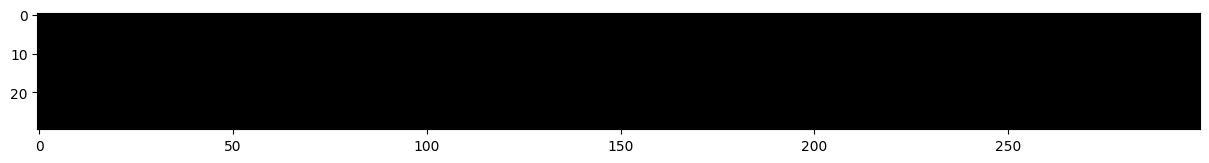

In [30]:
plt.figure(figsize = (15, 5))
plt.imshow(model[0].weights.data, cmap = 'gray');

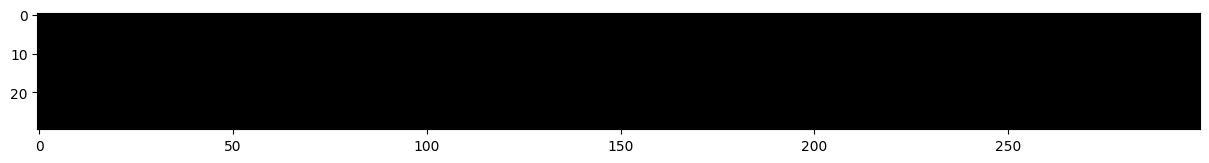

In [31]:
plt.figure(figsize = (15, 5))
plt.imshow(model[0].weights.grad, cmap = 'gray');

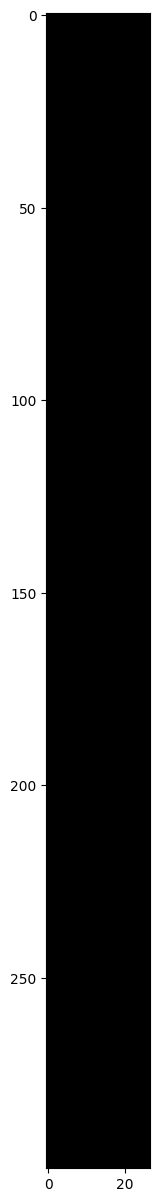

In [32]:
plt.figure(figsize = (5, 15))
plt.imshow(model[-1].weights.data, cmap = 'gray');

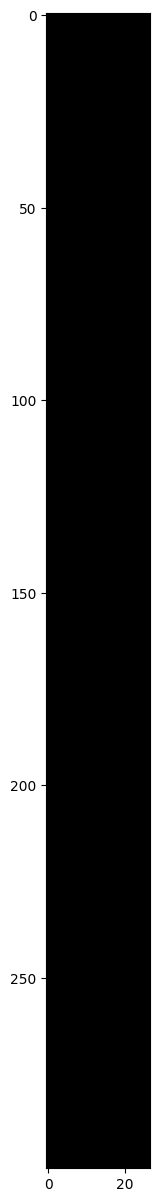

In [20]:
plt.figure(figsize = (5, 15))
plt.imshow(model[-1].weights.grad, cmap = 'gray');

In [33]:
model[-1].weights.grad.max(), model[-1].weights.grad.min()

(tensor(0.), tensor(0.))